In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
# File path to the dataset
file_path = r"C:\Users\adity\Downloads\Machine_learning\hackathon\dataset\Final dataset\balanced_training_data_smote.csv"

# Load the dataset
data = pd.read_csv(file_path)


In [3]:
# Assuming the target column is "SepsisLabel" and the rest are features
target_col = "SepsisLabel"
features = data.drop(columns=[target_col])
target = data[target_col]

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# Convert data into sequences for LSTM/RNN
sequence_length = 10  # Use 10 timesteps for each sequence
X = []
y = []

for i in range(len(features_scaled) - sequence_length):
    X.append(features_scaled[i:i + sequence_length])
    y.append(target[i + sequence_length])

# Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

# Create an LSTM model
model = Sequential()

# Add Input layer explicitly
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

# Add LSTM layers with dropout
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))

# Add output layer for binary classification
model.add(Dense(1, activation='sigmoid'))  # Sigmoid activation function for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [5]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # Use 20% of training data for validation
    epochs=5,            # Number of epochs
    batch_size=32,        # Batch size
    callbacks=[early_stopping],  # Early stopping callback
    verbose=1             # Display training progress
)


Epoch 1/5
48777/48777 ━━━━━━━━━━━━━━━━━━━━ 181s 4ms/step - accuracy: 0.9400 - loss: 0.1664 - val_accuracy: 0.9702 - val_loss: 0.0971
Epoch 2/5
48777/48777 ━━━━━━━━━━━━━━━━━━━━ 185s 4ms/step - accuracy: 0.9726 - loss: 0.0924 - val_accuracy: 0.9781 - val_loss: 0.0787
Epoch 3/5
48777/48777 ━━━━━━━━━━━━━━━━━━━━ 193s 4ms/step - accuracy: 0.9790 - loss: 0.0769 - val_accuracy: 0.9801 - val_loss: 0.0744
Epoch 4/5
48777/48777 ━━━━━━━━━━━━━━━━━━━━ 196s 4ms/step - accuracy: 0.9825 - loss: 0.0675 - val_accuracy: 0.9851 - val_loss: 0.0612
Epoch 5/5
48777/48777 ━━━━━━━━━━━━━━━━━━━━ 196s 4ms/step - accuracy: 0.9849 - loss: 0.0618 - val_accuracy: 0.9854 - val_loss: 0.0609


In [6]:
# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")


15243/15243 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - accuracy: 0.9856 - loss: 0.0606
Test Loss: 0.060452722012996674, Test Accuracy: 0.9855977296829224


In [7]:
# Save the model in the recommended Keras format
model.save("lstm_model.keras")


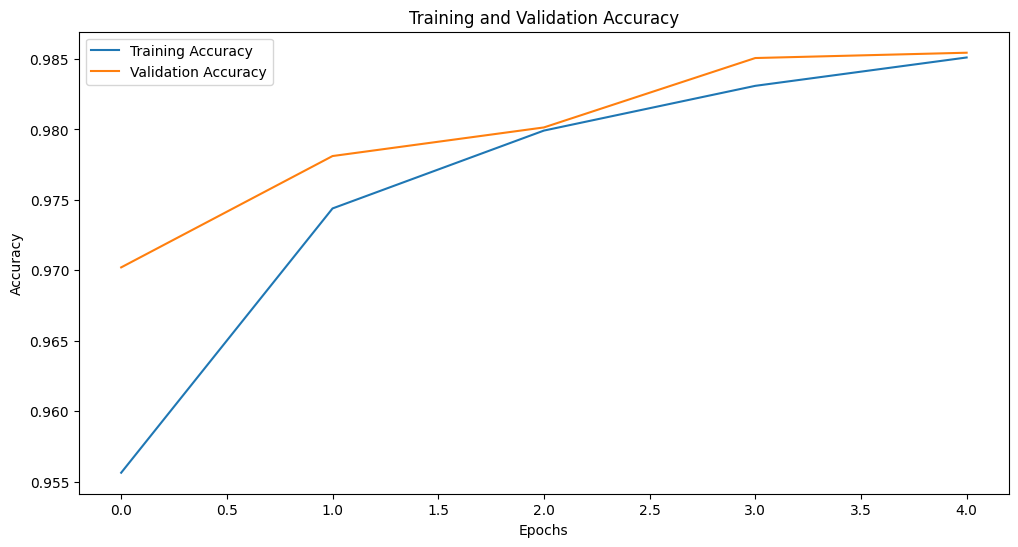

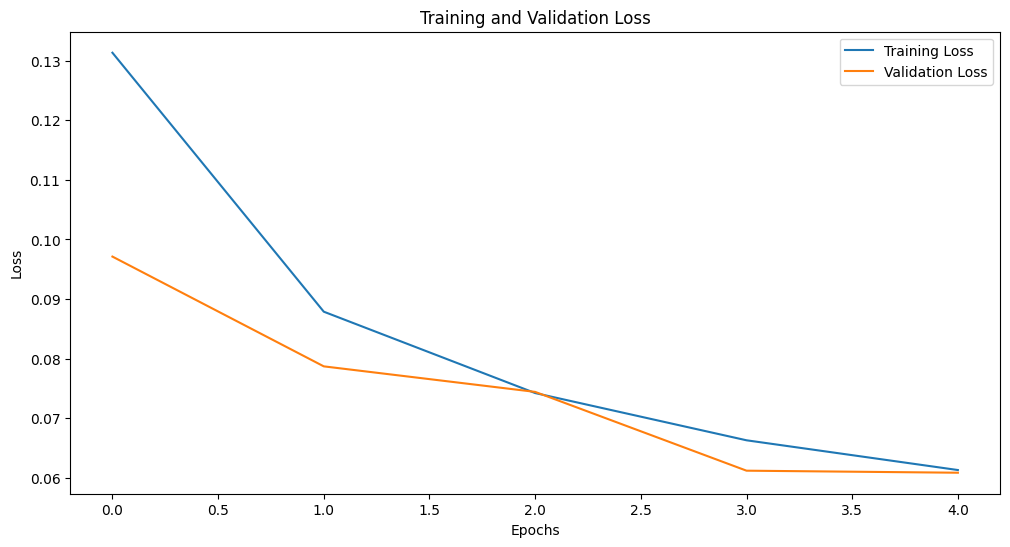

In [8]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


15243/15243 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step


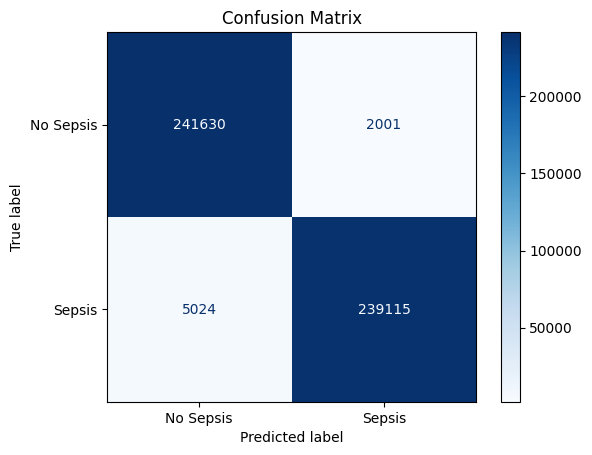

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict and binarize outputs
y_pred_binary = (model.predict(X_test) > 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Sepsis', 'Sepsis'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


In [10]:
from sklearn.metrics import classification_report

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_binary))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    243631
           1       0.99      0.98      0.99    244139

    accuracy                           0.99    487770
   macro avg       0.99      0.99      0.99    487770
weighted avg       0.99      0.99      0.99    487770



15243/15243 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step


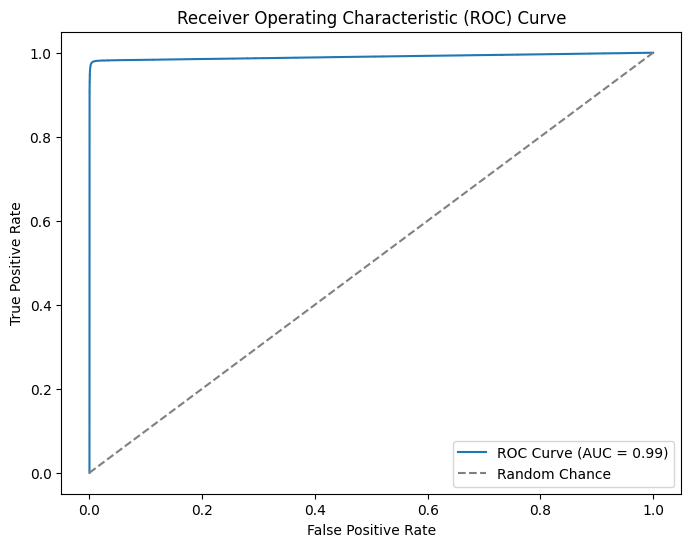

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


15243/15243 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step


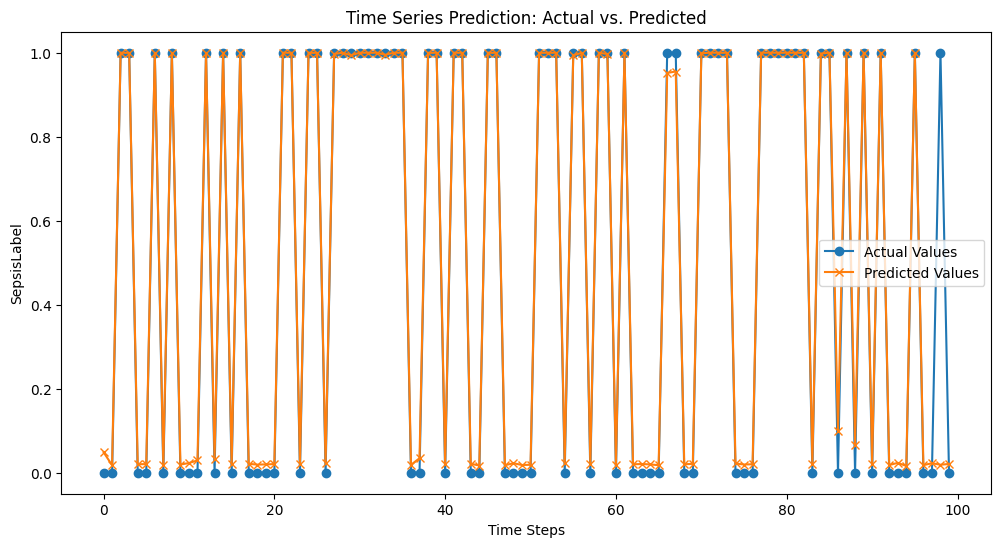

In [12]:
# Predict on test data
y_test_pred = model.predict(X_test)

# Plot actual vs. predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label='Actual Values', marker='o')  # Use first 100 for visibility
plt.plot(y_test_pred[:100], label='Predicted Values', marker='x')
plt.title('Time Series Prediction: Actual vs. Predicted')
plt.xlabel('Time Steps')
plt.ylabel('SepsisLabel')
plt.legend()
plt.show()


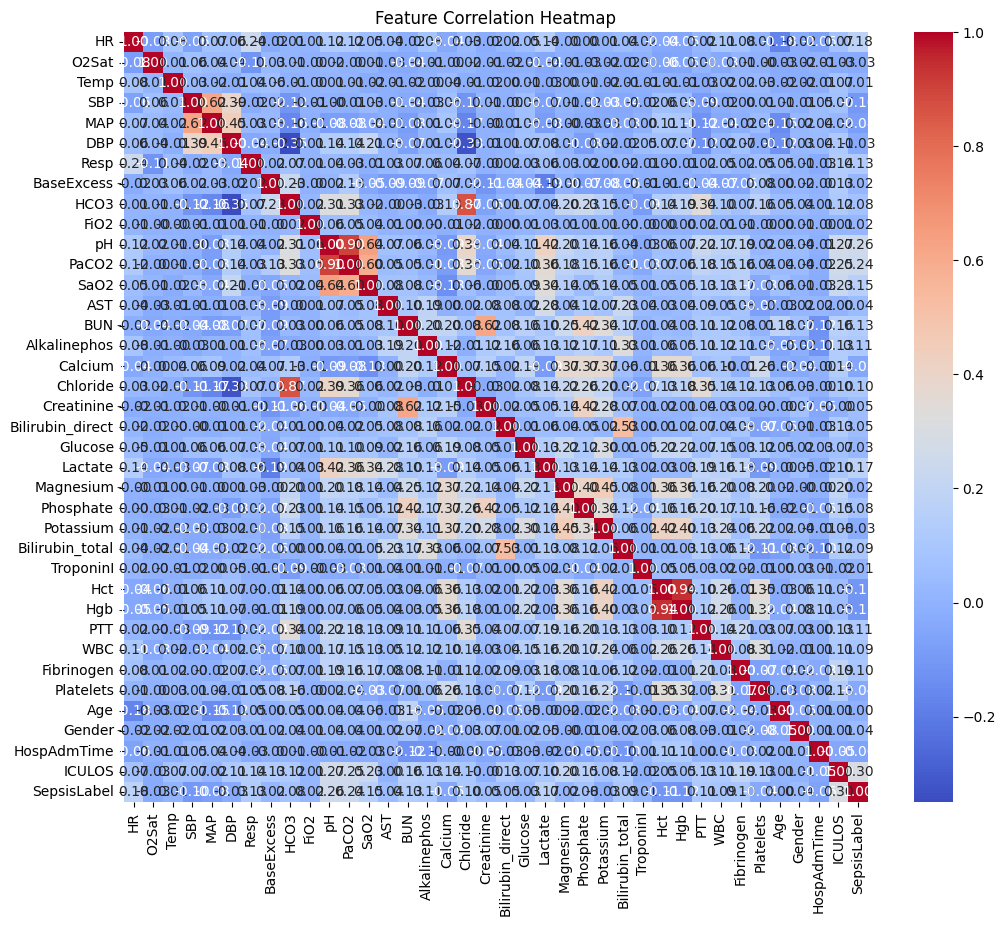

In [13]:
import seaborn as sns

# Compute correlation matrix
correlation_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


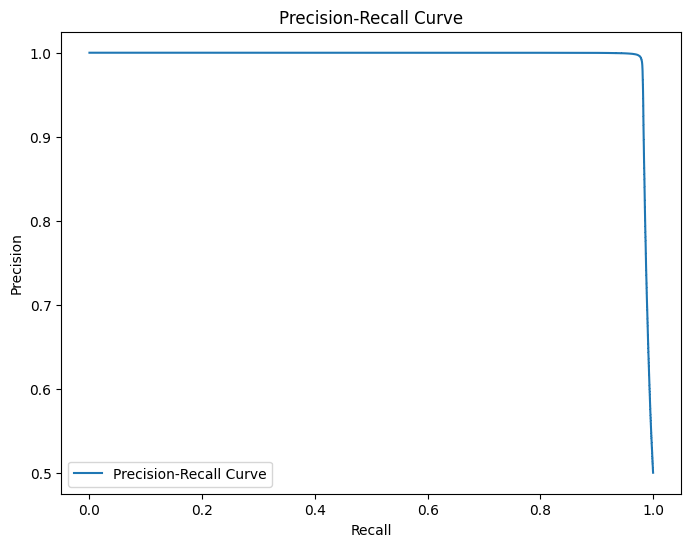

In [14]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


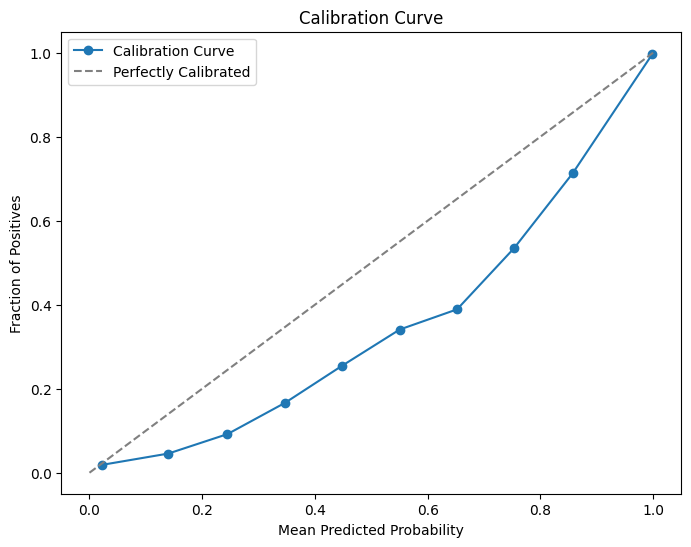

In [16]:
from sklearn.calibration import calibration_curve

# Compute calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

# Plot calibration curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()


15243/15243 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step


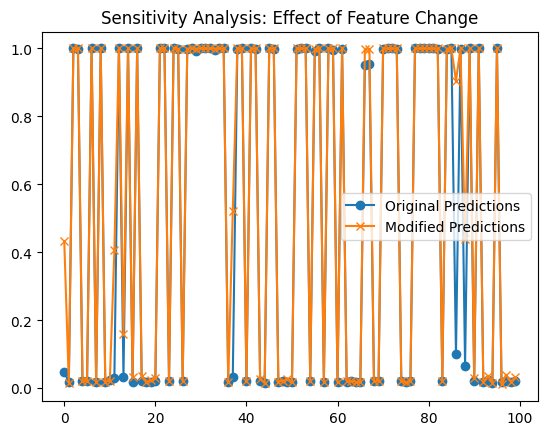

In [22]:
# Example: Vary a feature and observe changes in predictions
import numpy as np

# Choose a feature to vary (e.g., feature index 0)
varied_feature_index = 0
X_test_varied = X_test.copy()
X_test_varied[:, :, varied_feature_index] += 0.1  # Add a small increment

# Predict on modified dataset
y_varied_pred = model.predict(X_test_varied)

# Plot the effect
plt.plot(y_pred_prob[:100], label='Original Predictions', marker='o')
plt.plot(y_varied_pred[:100], label='Modified Predictions', marker='x')
plt.legend()
plt.title('Sensitivity Analysis: Effect of Feature Change')
plt.show()


In [23]:
import time

# Measure prediction time
start_time = time.time()
y_pred = model.predict(X_test)
end_time = time.time()

print(f"Prediction Time: {end_time - start_time:.4f} seconds for {len(X_test)} samples.")


15243/15243 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step
Prediction Time: 28.4468 seconds for 487770 samples.


In [36]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Reshape data for LIME (LIME works with 2D input, not sequences)
X_test_flat = X_test.reshape(X_test.shape[0], -1)  # Flatten sequences into single-dimensional features

# Create a wrapper for the prediction function
def predict_function(input_data):
    # Reshape the 2D input back to 3D format (batch_size, timesteps, features)
    reshaped_input = input_data.reshape(input_data.shape[0], X_test.shape[1], X_test.shape[2])
    # Get predictions from the model
    positive_prob = model.predict(reshaped_input)
    # Return probabilities for both classes: [1 - positive_prob, positive_prob]
    return np.hstack((1 - positive_prob, positive_prob))

# Create a LIME Tabular Explainer
explainer = LimeTabularExplainer(
    training_data=X_train.reshape(X_train.shape[0], -1),  # Flatten the training data
    mode="classification",
    feature_names=[f"Feature_{i}" for i in range(X_test_flat.shape[1])],
    class_names=["No Sepsis", "Sepsis"],
    verbose=True
)

# Select an instance to explain
sample_index = 0
sample_instance = X_test_flat[sample_index]

# Generate explanation
explanation = explainer.explain_instance(
    sample_instance,
    predict_function,  # Use the fixed wrapped prediction function
    num_features=10  # Number of features to explain
)

# Visualize the explanation
explanation.show_in_notebook(show_table=True, show_all=False)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Intercept 0.4982267007896875
Prediction_local [0.49822618]
Right: 0.49822626


In [ ]:
import re
import numpy as np
import pdfplumber
from tensorflow.keras.models import load_model

# Load the pre-trained LSTM model
model = load_model("lstm_model.keras")

# Function to extract text from a PDF
def extract_text_from_pdf(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text += page.extract_text()
    return text

# Function to extract features from the text
def extract_features_from_text(text):
    # Define the feature keys
    features = [
        "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "BaseExcess", "HCO3",
        "FiO2", "pH", "PaCO2", "SaO2", "AST", "BUN", "Alkalinephos", "Calcium",
        "Chloride", "Creatinine", "Bilirubin_direct", "Glucose", "Lactate",
        "Magnesium", "Phosphate", "Potassium", "Bilirubin_total", "TroponinI",
        "Hct", "Hgb", "PTT", "WBC", "Fibrinogen", "Platelets", "Age", "Gender"
    ]
    feature_values = []

    # Extract each feature using regex
    for feature in features:
        match = re.search(fr"{feature}:\s*([\d.]+)", text)
        if match:
            feature_values.append(float(match.group(1)))
        else:
            feature_values.append(0)  # Use 0 if the feature is missing

    # Handle Gender separately
    gender_match = re.search(r"Gender:\s*(Male|Female)", text, re.IGNORECASE)
    if gender_match:
        gender_value = 1 if gender_match.group(1).lower() == "male" else 0
        feature_values[-1] = gender_value  # Replace the Gender value

    return np.array([feature_values])

# Function to predict sepsis
def predict_sepsis(features):
    prediction = model.predict(features)
    return prediction[0][0]

# Process a single PDF and predict sepsis
def process_pdf(pdf_path):
    # Step 1: Extract text from the PDF
    pdf_text = extract_text_from_pdf(pdf_path)

    # Step 2: Extract features from the text
    features = extract_features_from_text(pdf_text)

    # Step 3: Predict sepsis using the model
    sepsis_probability = predict_sepsis(features)
    sepsis_label = "Positive" if sepsis_probability > 0.5 else "Negative"

    # Print results
    print(f"Sepsis Prediction: {sepsis_label}")
    print(f"Sepsis Probability: {sepsis_probability:.2f}")

# Example usage
if __name__ == "__main__":
    pdf_file_path = "path_to_your_pdf_file.pdf"  # Replace with your PDF file path
    process_pdf(pdf_file_path)
